# TalentMatch — Learning to Rank Pipeline (Improved)

**Improvements over baseline:**
- 35+ engineered features (vs 17 in baseline)
- Title seniority extraction & title-to-title match
- Certification overlap features
- Job-level aggregated statistics (per-job candidate pool context)
- Skill category overlap (grouped skills by domain)
- Ensemble: HistGradientBoostingRegressor + HistGradientBoostingClassifier (expected relevance)
- Per-job score rank normalisation
- OOF target encoding for `industry`, `current_title`, `job_title`
- Better salary normalisation (company-size-aware)

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from collections import Counter
from sklearn.model_selection import GroupKFold
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

C:\Users\moein\AnacondaNew\Lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:15: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


## 1. Load Data

In [95]:
apps_train = pd.read_csv('applications_train.csv')
apps_test = pd.read_csv('applications_test.csv')
candidates = pd.read_csv('candidates.csv')
jobs = pd.read_csv('jobs.csv')

apps_train['application_date'] = pd.to_datetime(apps_train['application_date'])
apps_test['application_date'] = pd.to_datetime(apps_test['application_date'])

print(f"applications_train: {apps_train.shape}")
print(f"applications_test:  {apps_test.shape}")
print(f"candidates:         {candidates.shape}")
print(f"jobs:               {jobs.shape}\n")

apps_train.head(3)


applications_train: (118772, 5)
applications_test:  (52700, 4)
candidates:         (50000, 14)
jobs:               (5000, 13)



,application_id,job_id,candidate_id,application_date,relevance_label
0,206,6,31050,2023-11-26,2
1,207,6,19239,2023-11-16,1
2,208,6,34280,2023-11-26,2


## 2. Exploratory Data Analysis

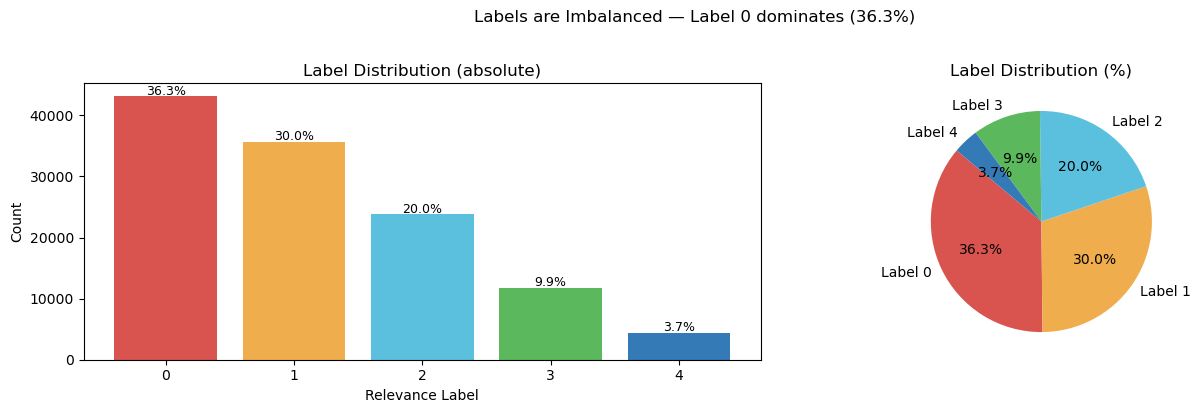

relevance_label
0    43080
1    35645
2    23789
3    11811
4     4447
Name: count, dtype: int64


In [96]:
COLORS = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c', '#337ab7']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_counts = apps_train['relevance_label'].value_counts().sort_index()
label_pct = label_counts / label_counts.sum() * 100

axes[0].bar(label_counts.index, label_counts.values, color=COLORS)
for i, (v, p) in enumerate(zip(label_counts.values, label_pct.values)):
    axes[0].text(i, v + 300, f'{p:.1f}%', ha='center', fontsize=9)

axes[0].set_xlabel('Relevance Label')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution (absolute)')

axes[1].pie(
    label_pct.values, 
    labels=[f'Label {i}' for i in range(5)],
    autopct='%1.1f%%', 
    startangle=140, 
    colors=COLORS
)
axes[1].set_title('Label Distribution (%)')

plt.suptitle('Labels are Imbalanced — Label 0 dominates (36.3%)', y=1.02)
plt.tight_layout()
plt.show()

print(label_counts)


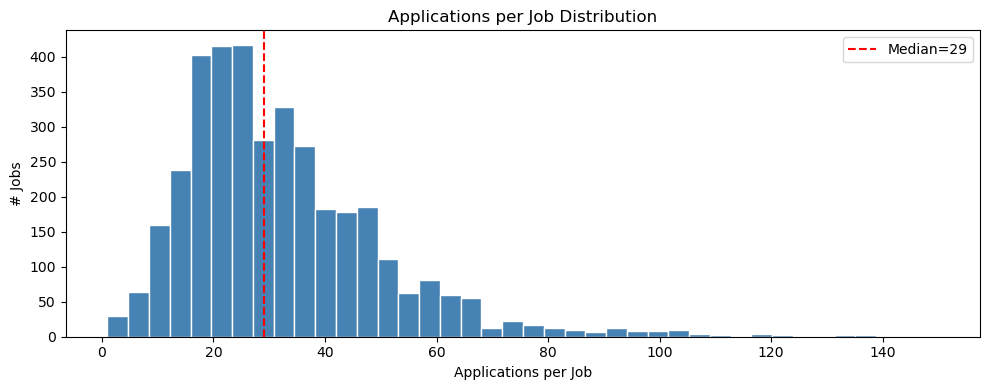

count    3667.000000
mean       32.389419
std        18.319555
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       150.000000
dtype: float64


In [97]:
apps_per_job = apps_train.groupby('job_id').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(apps_per_job, bins=40, color='steelblue', edgecolor='white')
ax.axvline(
    apps_per_job.median(), 
    color='red', 
    linestyle='--', 
    label=f'Median={apps_per_job.median():.0f}'
)

ax.set_xlabel('Applications per Job')
ax.set_ylabel('# Jobs')
ax.set_title('Applications per Job Distribution')
ax.legend()

plt.tight_layout()
plt.show()

print(apps_per_job.describe())


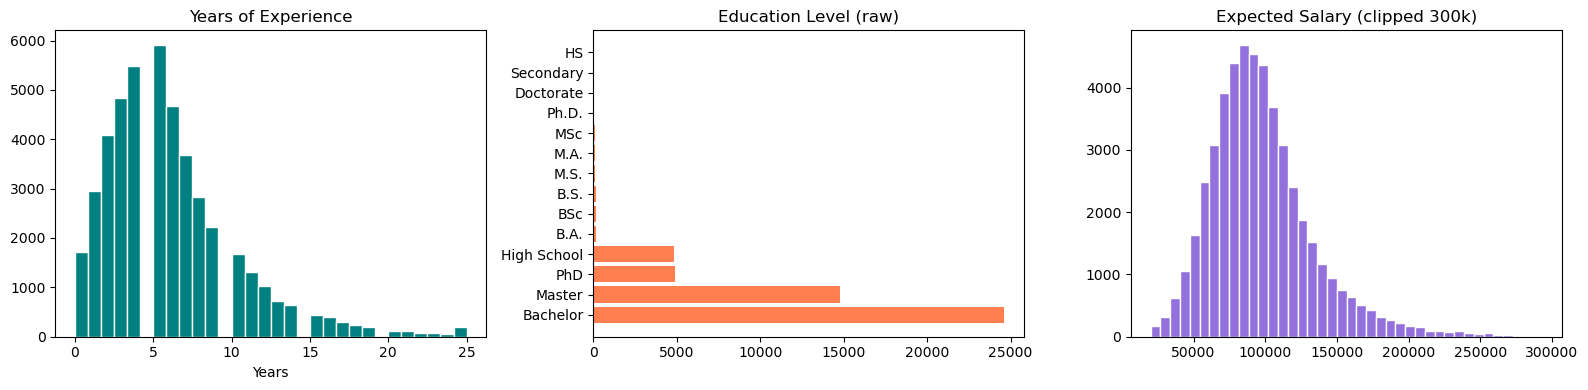

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(
    candidates['years_experience'].dropna(), 
    bins=30, 
    color='teal', 
    edgecolor='white'
)
axes[0].set_title('Years of Experience')
axes[0].set_xlabel('Years')

edu_counts = candidates['education_level'].value_counts()
axes[1].barh(edu_counts.index, edu_counts.values, color='coral')
axes[1].set_title('Education Level (raw)')

axes[2].hist(
    candidates['expected_salary'].dropna().clip(upper=300_000),
    bins=40, 
    color='mediumpurple', 
    edgecolor='white'
)
axes[2].set_title('Expected Salary (clipped 300k)')

plt.tight_layout()
plt.show()


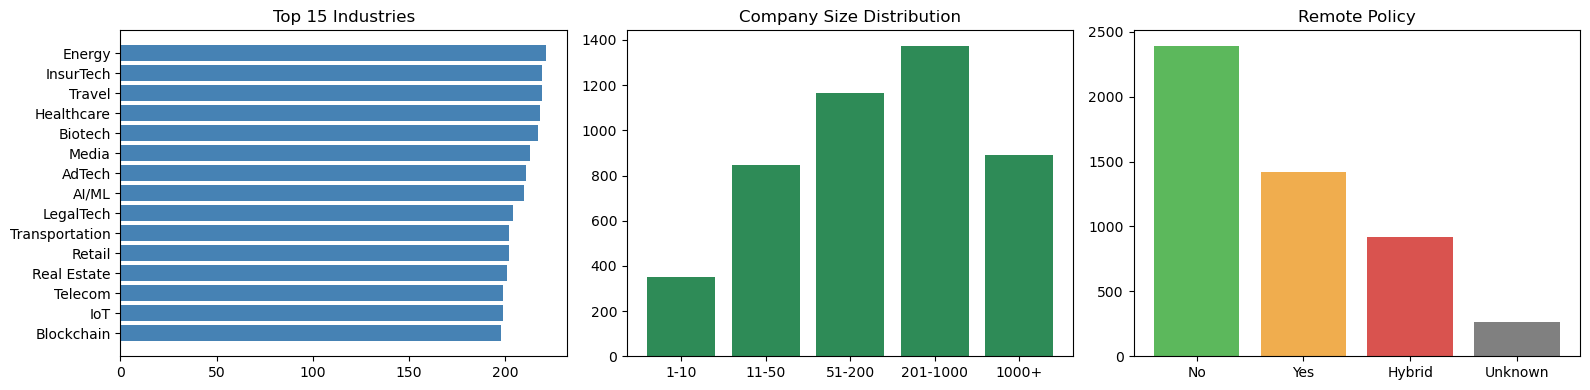

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ind_counts = jobs['industry'].value_counts().head(15)
axes[0].barh(ind_counts.index[::-1], ind_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Industries')

size_order = ['1-10', '11-50', '51-200', '201-1000', '1000+']
cs = jobs['company_size'].value_counts().reindex(size_order, fill_value=0)
axes[1].bar(cs.index, cs.values, color='seagreen')
axes[1].set_title('Company Size Distribution')

ra = jobs['remote_allowed'].fillna('Unknown').value_counts()
axes[2].bar(
    ra.index, 
    ra.values, 
    color=['#5cb85c', '#f0ad4e', '#d9534f', 'gray'][:len(ra)]
)
axes[2].set_title('Remote Policy')

plt.tight_layout()
plt.show()


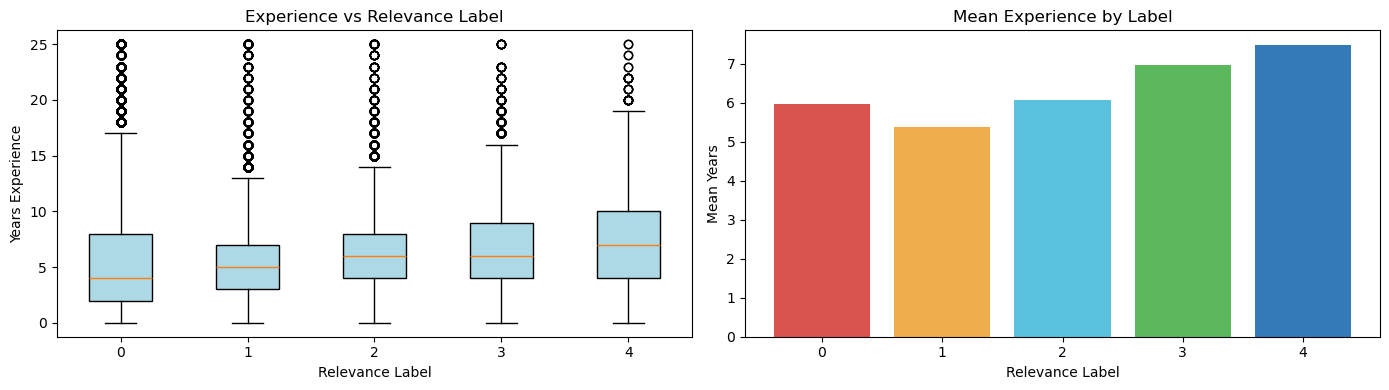

→ Clear positive correlation: higher relevance = more experience


In [100]:
merged_eda = apps_train.merge(
    candidates[['candidate_id', 'years_experience']], 
    on='candidate_id', 
    how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

data_by_label = [
    merged_eda[merged_eda.relevance_label == lbl]['years_experience'].dropna() 
    for lbl in range(5)
]
axes[0].boxplot(
    data_by_label, 
    labels=[str(i) for i in range(5)], 
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[0].set_xlabel('Relevance Label')
axes[0].set_ylabel('Years Experience')
axes[0].set_title('Experience vs Relevance Label')

mean_exp = merged_eda.groupby('relevance_label')['years_experience'].mean()
axes[1].bar(mean_exp.index, mean_exp.values, color=COLORS)
axes[1].set_xlabel('Relevance Label')
axes[1].set_ylabel('Mean Years')
axes[1].set_title('Mean Experience by Label')

plt.tight_layout()
plt.show()

print('→ Clear positive correlation: higher relevance = more experience')


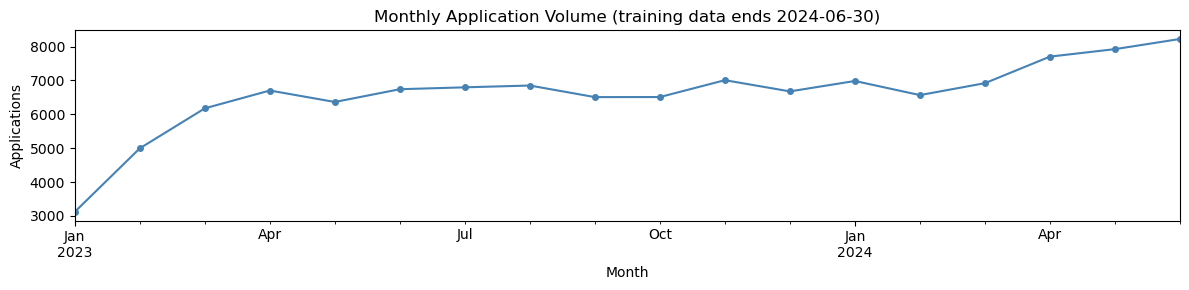

In [101]:
monthly = apps_train.set_index('application_date').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 3))

monthly.plot(ax=ax, color='steelblue', marker='o', markersize=4)

ax.set_title('Monthly Application Volume (training data ends 2024-06-30)')
ax.set_xlabel('Month')
ax.set_ylabel('Applications')

plt.tight_layout()
plt.show()


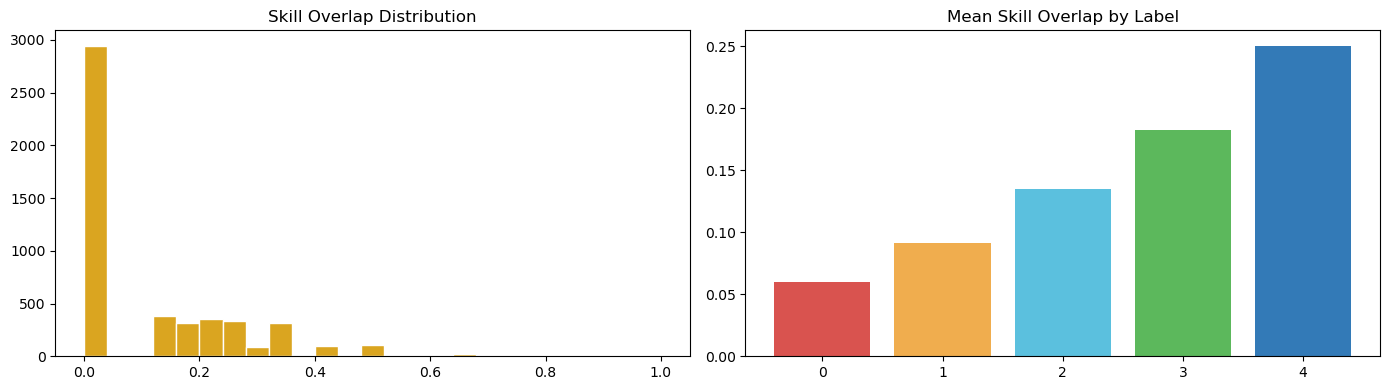

→ Skill overlap is a strong signal (monotonically increasing with label):
relevance_label
0    0.060
1    0.092
2    0.135
3    0.183
4    0.251
Name: overlap, dtype: float64


In [102]:
SEED = 42

def skill_overlap_ratio_simple(cand, job):
    if pd.isna(cand) or pd.isna(job):
        return 0.0
    
    cs = set(x.strip().lower() for x in str(cand).split('|'))
    js = set(x.strip().lower() for x in str(job).split('|'))
    
    return len(cs & js) / len(js) if js else 0.0


sample = apps_train.sample(5000, random_state=SEED).copy()

sample = sample.merge(
    candidates[['candidate_id', 'skills']], 
    on='candidate_id', 
    how='left'
)
sample = sample.merge(
    jobs[['job_id', 'required_skills']], 
    on='job_id', 
    how='left'
)

sample['overlap'] = sample.apply(
    lambda r: skill_overlap_ratio_simple(r['skills'], r['required_skills']), 
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    sample['overlap'], 
    bins=25, 
    color='goldenrod', 
    edgecolor='white'
)
axes[0].set_title('Skill Overlap Distribution')

mo = sample.groupby('relevance_label')['overlap'].mean()

axes[1].bar(mo.index, mo.values, color=COLORS)
axes[1].set_title('Mean Skill Overlap by Label')

plt.tight_layout()
plt.show()

print('→ Skill overlap is a strong signal (monotonically increasing with label):')
print(mo.round(3))


In [103]:
print('=== Candidate missing values ===')
print(candidates.isnull().sum()[candidates.isnull().sum() > 0])
print()

print('=== Job missing values ===')
print(jobs.isnull().sum()[jobs.isnull().sum() > 0])
print()

print('=== Salary currency variants (messy) ===')
print(jobs['salary_currency'].value_counts())


=== Candidate missing values ===
years_experience        4041
university             12338
previous_companies     13465
certifications         28179
english_proficiency     5129
willing_to_relocate     7707
dtype: int64

=== Job missing values ===
required_skills         248
min_years_experience    105
max_years_experience    495
remote_allowed          265
company_size            377
dtype: int64

=== Salary currency variants (messy) ===
salary_currency
USD      2994
EUR      1192
IRR       718
usd        33
USD        13
eur        12
USD        11
irr         8
EUR         7
EUR         6
IRR         3
IRR         3
Name: count, dtype: int64


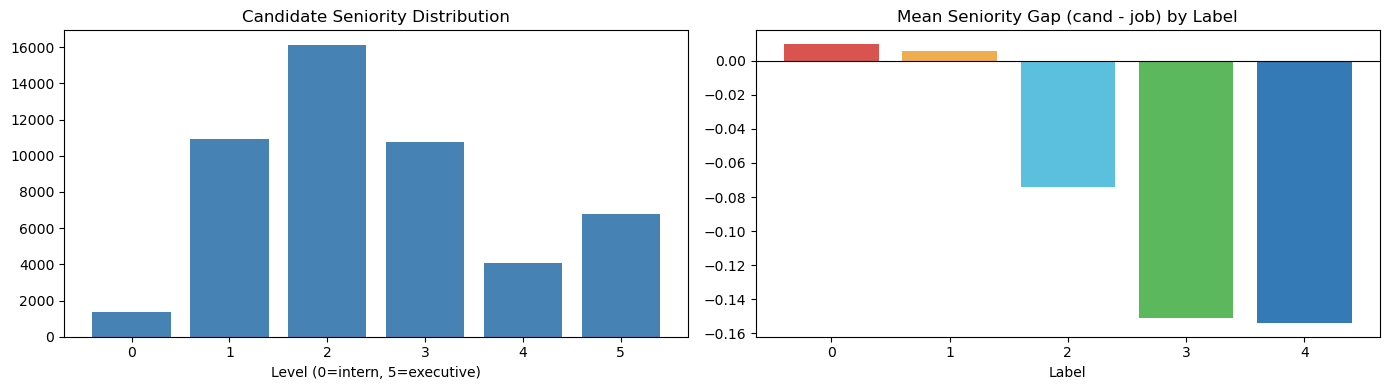

→ Seniority gap near 0 = better match (higher label)
relevance_label
0    0.010
1    0.005
2   -0.074
3   -0.151
4   -0.154
Name: sen_gap, dtype: float64


In [104]:
SENIORITY_PATTERNS = [
    (r'\bintern\b|\btrainee\b', 0),
    (r'\bjunior\b|\bjr\.?\b', 1),
    (r'\bmid\b|\bstaff\b', 2),
    (r'\bsenior\b|\bsr\.?\b', 3),
    (r'\blead\b|\bprincipal\b', 4),
    (r'\bstaff\b', 4),
    (r'\bmanager\b|\bdirector\b|\bhead\b|\bvp\b|\bcto\b|\bceo\b', 5),
]

def extract_seniority(title):
    if pd.isna(title):
        return 2
        
    t = str(title).lower()
    for pat, level in reversed(SENIORITY_PATTERNS):
        if re.search(pat, t):
            return level
            
    return 2  

cand_seniority = candidates['current_title'].map(extract_seniority)
job_seniority = jobs['job_title'].map(extract_seniority)

merged_sen = apps_train.merge(
    candidates[['candidate_id']].assign(cand_sen=cand_seniority),
    on='candidate_id',
    how='left'
).merge(
    jobs[['job_id']].assign(job_sen=job_seniority),
    on='job_id',
    how='left'
)

merged_sen['sen_gap'] = merged_sen['cand_sen'] - merged_sen['job_sen']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cand_counts = [cand_seniority[cand_seniority == i].count() for i in range(6)]
axes[0].bar(range(6), cand_counts, color='steelblue')
axes[0].set_title('Candidate Seniority Distribution')
axes[0].set_xlabel('Level (0=intern, 5=executive)')

mean_sg = merged_sen.groupby('relevance_label')['sen_gap'].mean()

axes[1].bar(mean_sg.index, mean_sg.values, color=COLORS)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean Seniority Gap (cand - job) by Label')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

print('→ Seniority gap near 0 = better match (higher label)')
print(mean_sg.round(3))


## 3. Preprocessing & Data Cleaning

In [105]:
IRR_TO_USD = 1 / 42_000
EUR_TO_USD = 1.10

def normalize_currency_col(df, col):
    df = df.copy()
    curr = df['salary_currency'].str.strip().str.upper().fillna('USD')
    df[col] = df[col].astype(float)
    
    df.loc[curr == 'IRR', col] *= IRR_TO_USD
    df.loc[curr == 'EUR', col] *= EUR_TO_USD
    
    return df

jobs_c = normalize_currency_col(jobs, 'salary_min')
jobs_c = normalize_currency_col(jobs_c, 'salary_max')

print('Salary_min after normalisation:')
print(jobs_c['salary_min'].describe().round(0))


Salary_min after normalisation:
count      5000.0
mean      90442.0
std       48903.0
min       30000.0
25%       60000.0
50%       79000.0
75%      140000.0
max      224400.0
Name: salary_min, dtype: float64


In [106]:
cands_c = candidates.copy()  

EDU_MAP = {
    'high school': 1, 'hs': 1, 'secondary': 1,
    'bachelor': 2, 'b.a.': 2, 'b.s.': 2, 'bsc': 2,
    'master': 3, 'm.s.': 3, 'm.a.': 3, 'msc': 3,
    'phd': 4, 'ph.d.': 4, 'doctorate': 4,
}

ENG_MAP = {
    'a1': 1, 'beginner': 1,
    'a2': 2, 'elementary': 2,
    'b1': 3, 'intermediate': 3,
    'b2': 4, 'upper-intermediate': 4,
    'c1': 5, 'advanced': 5,
    'c2': 6, 'fluent': 6, 'bilingual': 6, 'native': 6,
}

cands_c['education_num'] = cands_c['education_level'].map(
    lambda v: EDU_MAP.get(str(v).strip().lower(), np.nan) if pd.notna(v) else np.nan
)

cands_c['english_num'] = cands_c['english_proficiency'].map(
    lambda v: ENG_MAP.get(str(v).strip().lower(), np.nan) if pd.notna(v) else np.nan
)

cands_c['relocate_num'] = cands_c['willing_to_relocate'].map({'Yes': 1, 'No': 0})
jobs_c['company_size_num'] = jobs_c['company_size'].map({'1-10': 1, '11-50': 2, '51-200': 3, '201-1000': 4, '1000+': 5})
jobs_c['remote_num'] = jobs_c['remote_allowed'].map({'No': 0, 'Hybrid': 1, 'Yes': 2})

cands_c['cand_loc'] = cands_c['candidate_location'].fillna('unknown').str.strip().str.lower()
jobs_c['job_loc'] = jobs_c['job_location'].fillna('unknown').str.strip().str.lower()

cands_c['cand_seniority'] = cands_c['current_title'].map(extract_seniority)
jobs_c['job_seniority'] = jobs_c['job_title'].map(extract_seniority)

cands_c['num_certs'] = cands_c['certifications'].apply(
    lambda x: len(str(x).split('|')) if pd.notna(x) else 0
)

cands_c['num_prev_companies'] = cands_c['previous_companies'].apply(
    lambda x: len(str(x).split('|')) if pd.notna(x) else 0
)

print('Preprocessing complete.')
print('Education levels:', cands_c['education_num'].value_counts().sort_index().to_dict())
print('English levels:  ', cands_c['english_num'].value_counts().sort_index().to_dict())


Preprocessing complete.
Education levels: {1: 4903, 2: 25048, 3: 15032, 4: 5017}
English levels:   {1.0: 6691, 2.0: 8267, 3.0: 7428, 4.0: 7358, 5.0: 7489, 6.0: 7638}


## 4. Skill Category Grouping

In [107]:
SKILL_CATEGORIES = {
    'cloud': {'aws-csa', 'aws-sap', 'aws-dva', 'gcp-ace', 'gcp-pca', 'azure-az104', 'azure-az305',
              'azure-az900', 'aws', 'gcp', 'azure', 'cloud', 'terraform', 'ansible', 'pulumi'},
    'data': {'python', 'r', 'sql', 'postgresql', 'mysql', 'mongodb', 'redis', 'cassandra', 'dbt',
             'spark', 'hadoop', 'kafka', 'tableau', 'powerbi', 'snowflake', 'databricks',
             'pandas', 'numpy', 'matplotlib', 'seaborn', 'jupyter'},
    'ml': {'tensorflow', 'pytorch', 'scikit-learn', 'ml', 'machine learning', 'deep learning',
           'nlp', 'computer vision', 'keras', 'xgboost', 'lightgbm'},
    'frontend': {'react', 'vue', 'angular', 'svelte', 'html', 'css', 'sass', 'scss', 'typescript',
                 'javascript', 'next.js', 'nuxt', 'redux', 'webpack', 'tailwind'},
    'backend': {'python', 'java', 'node.js', 'spring', 'django', 'fastapi', 'flask', 'go', 'rust',
                'c#', 'php', 'laravel', 'express', 'rails', 'rest api', 'graphql', 'grpc'},
    'devops': {'docker', 'kubernetes', 'jenkins', 'gitlab-ci', 'github actions', 'cicd', 'ci/cd',
               'terraform', 'ansible', 'nginx', 'linux', 'bash', 'prometheus', 'grafana'},
    'mobile': {'swift', 'kotlin', 'flutter', 'react native', 'ios', 'android', 'mobile'},
    'security': {'ceh', 'cissp', 'pci-dss', 'hipaa', 'soc2', 'security', 'penetration testing', 'oauth'},
    'pm': {'scrum', 'agile', 'pmp', 'jira', 'kanban', 'project management', 'scrum-master'},
}

def get_skill_categories(skill_str):
    if pd.isna(skill_str):
        return set()
        
    skills = set(x.strip().lower() for x in str(skill_str).split('|'))
    cats = set()
    
    for cat, cat_skills in SKILL_CATEGORIES.items():
        if skills & cat_skills:
            cats.add(cat)
            
    return cats

def parse_skills(s):
    if pd.isna(s):
        return set()
    return set(x.strip().lower() for x in str(s).split('|') if x.strip())

cand_skills_dict = {r.candidate_id: parse_skills(r.skills) for r in cands_c.itertuples(index=False)}
job_skills_dict = {r.job_id: parse_skills(r.required_skills) for r in jobs_c.itertuples(index=False)}

cand_cats_dict = {r.candidate_id: get_skill_categories(r.skills) for r in cands_c.itertuples(index=False)}
job_cats_dict = {r.job_id: get_skill_categories(r.required_skills) for r in jobs_c.itertuples(index=False)}

cand_certs_dict = {r.candidate_id: parse_skills(r.certifications) for r in cands_c.itertuples(index=False)}

print('Skill dicts built:', len(cand_skills_dict), 'candidates,', len(job_skills_dict), 'jobs')

cat_counts = Counter(cat for cats in cand_cats_dict.values() for cat in cats)

print('\nSkill category frequency in candidates:')
for k, v in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:15s}: {v:6d}')

Skill dicts built: 50000 candidates, 5000 jobs

Skill category frequency in candidates:
  frontend       :  43477
  data           :  40857
  backend        :  37588
  devops         :  36327
  ml             :  23390
  cloud          :  18363
  pm             :   6263


## 5. Feature Engineering (35+ features)

In [108]:
GLOBAL_EXP_MEDIAN = cands_c['years_experience'].median()
GLOBAL_SAL_MEDIAN = cands_c['expected_salary'].median()

def build_features(df, cands_df, jobs_df):
    
    cc = [
        'candidate_id', 'years_experience', 'education_num', 'english_num',
        'expected_salary', 'relocate_num', 'profile_completeness', 'cand_loc',
        'cand_seniority', 'num_certs', 'num_prev_companies'
    ]
    jc = [
        'job_id', 'min_years_experience', 'max_years_experience',
        'salary_min', 'salary_max', 'company_size_num', 'remote_num',
        'job_loc', 'job_seniority'
    ]

    m = df[['job_id', 'candidate_id']].copy()
    m = m.merge(cands_df[cc], on='candidate_id', how='left')
    m = m.merge(jobs_df[jc], on='job_id', how='left')

    f = pd.DataFrame(index=m.index)

    f['years_exp'] = m['years_experience'].fillna(GLOBAL_EXP_MEDIAN)
    f['edu_num'] = m['education_num'].fillna(2)
    f['eng_num'] = m['english_num'].fillna(3)
    f['profile_comp'] = m['profile_completeness'].fillna(50)
    f['relocate'] = m['relocate_num'].fillna(0)
    f['cand_seniority'] = m['cand_seniority'].fillna(2)
    f['num_certs'] = m['num_certs'].fillna(0)
    f['num_prev_companies'] = m['num_prev_companies'].fillna(0)

    jmin = m['min_years_experience'].fillna(0)
    jmax = m['max_years_experience'].fillna(m['max_years_experience'].median())
    jmid = (jmin + jmax) / 2
    
    f['job_min_exp'] = jmin
    f['job_max_exp'] = jmax
    
    sal_mid = ((m['salary_min'] + m['salary_max']) / 2).fillna(80_000)
    f['sal_mid'] = sal_mid
    f['company_size'] = m['company_size_num'].fillna(3)
    f['remote'] = m['remote_num'].fillna(0)
    f['job_seniority'] = m['job_seniority'].fillna(2)

    n = len(m)
    sor = np.zeros(n)
    soa = np.zeros(n)
    msk = np.zeros(n)
    ext = np.zeros(n)
    scat = np.zeros(n)
    scat_r = np.zeros(n)
    tot_c = np.zeros(n)
    tot_j = np.zeros(n)

    job_ids = m['job_id'].values
    cand_ids = m['candidate_id'].values

    for i, (jid, cid) in enumerate(zip(job_ids, cand_ids)):
        js = job_skills_dict.get(jid, set())
        cs = cand_skills_dict.get(cid, set())
        jc_cats = job_cats_dict.get(jid, set())
        cc_cats = cand_cats_dict.get(cid, set())

        tot_c[i] = len(cs)
        tot_j[i] = len(js)
        
        if js:
            ov = len(cs & js)
            soa[i] = ov
            sor[i] = ov / len(js)
            msk[i] = len(js - cs)
            
        ext[i] = len(cs - js) if js else len(cs)

        if jc_cats:
            cat_ov = len(cc_cats & jc_cats)
            scat[i] = cat_ov
            scat_r[i] = cat_ov / len(jc_cats)

    f['skill_overlap_ratio'] = sor
    f['skill_overlap_abs'] = soa
    f['missing_skills'] = msk
    f['extra_skills'] = ext
    f['skill_cat_overlap'] = scat
    f['skill_cat_ratio'] = scat_r
    f['total_skills_cand'] = tot_c
    f['total_skills_job'] = tot_j
    f['skills_density'] = tot_c / (tot_j + 1)

    ce = f['years_exp']
    f['exp_gap_mid'] = ce - jmid
    f['exp_below_min'] = np.maximum(0, jmin - ce)
    f['exp_above_max'] = np.maximum(0, ce - jmax)
    f['exp_in_range'] = ((ce >= jmin) & (ce <= jmax)).astype(int)
    f['exp_squared'] = ce ** 2

    csal = m['expected_salary'].fillna(GLOBAL_SAL_MEDIAN)
    f['sal_mismatch'] = csal - sal_mid
    f['sal_affordable'] = ((csal >= m['salary_min'].fillna(0)) & 
                           (csal <= m['salary_max'].fillna(999_999))).astype(int)
    f['sal_ratio'] = (csal / sal_mid.replace(0, np.nan)).fillna(1).clip(0.1, 10)
    f['sal_log_ratio'] = np.log(f['sal_ratio'].clip(0.01, 100))
    f['sal_rel_market'] = (csal / GLOBAL_SAL_MEDIAN).clip(0.1, 20)

    jed = jmin.map(lambda x: 1 if x < 1 else (2 if x < 3 else 3))
    f['edu_gap'] = f['edu_num'] - jed

    cloc = m['cand_loc']
    jloc = m['job_loc']
    remote_ok = m['remote_num'].fillna(0) >= 1
    lm = np.zeros(n)
    
    for i in range(n):
        cl = cloc.iloc[i]
        jl = jloc.iloc[i]
        if cl == jl:
            lm[i] = 2
        elif remote_ok.iloc[i] or cl == 'remote':
            lm[i] = 1
            
    f['loc_match'] = lm

    cs_arr = f['cand_seniority'].values
    js_arr = f['job_seniority'].values
    
    f['seniority_gap'] = cs_arr - js_arr
    f['seniority_gap_abs'] = np.abs(cs_arr - js_arr)
    f['seniority_match'] = (cs_arr == js_arr).astype(int)

    f['reloc_x_mismatch'] = f['relocate'] * (lm == 0).astype(int)
    f['experience_x_overlap'] = f['years_exp'] * f['skill_overlap_ratio']
    f['overlap_x_inrange'] = f['skill_overlap_ratio'] * f['exp_in_range']
    f['edu_x_overlap'] = f['edu_num'] * f['skill_overlap_ratio']
    f['eng_x_seniority'] = f['eng_num'] * f['cand_seniority']
    f['profile_x_overlap'] = f['profile_comp'] * f['skill_overlap_ratio']
    f['cert_count_x_overlap'] = f['num_certs'] * f['skill_overlap_ratio']

    return f

sample_feat = build_features(apps_train.head(100), cands_c, jobs_c)

print(f'Feature matrix shape: {sample_feat.shape}')
print('Features:', sample_feat.columns.tolist())
print('\nNull check:', sample_feat.isnull().sum().sum(), 'nulls total')


Feature matrix shape: (100, 45)
Features: ['years_exp', 'edu_num', 'eng_num', 'profile_comp', 'relocate', 'cand_seniority', 'num_certs', 'num_prev_companies', 'job_min_exp', 'job_max_exp', 'sal_mid', 'company_size', 'remote', 'job_seniority', 'skill_overlap_ratio', 'skill_overlap_abs', 'missing_skills', 'extra_skills', 'skill_cat_overlap', 'skill_cat_ratio', 'total_skills_cand', 'total_skills_job', 'skills_density', 'exp_gap_mid', 'exp_below_min', 'exp_above_max', 'exp_in_range', 'exp_squared', 'sal_mismatch', 'sal_affordable', 'sal_ratio', 'sal_log_ratio', 'sal_rel_market', 'edu_gap', 'loc_match', 'seniority_gap', 'seniority_gap_abs', 'seniority_match', 'reloc_x_mismatch', 'experience_x_overlap', 'overlap_x_inrange', 'edu_x_overlap', 'eng_x_seniority', 'profile_x_overlap', 'cert_count_x_overlap']

Null check: 0 nulls total


## 6. Job-Level Contextual Features

In [109]:
def build_job_context_features(df, feature_df):
    ctx = pd.DataFrame(index=df.index)
    ctx['job_id'] = df['job_id'].values
    ctx['skill_overlap_ratio'] = feature_df['skill_overlap_ratio'].values
    ctx['years_exp'] = feature_df['years_exp'].values
    ctx['sal_ratio'] = feature_df['sal_ratio'].values

    ctx['skill_overlap_rank_pct'] = ctx.groupby('job_id')['skill_overlap_ratio'].rank(pct=True)
    ctx['exp_rank_pct'] = ctx.groupby('job_id')['years_exp'].rank(pct=True)
    ctx['sal_rank_pct'] = ctx.groupby('job_id')['sal_ratio'].rank(pct=True)

    job_med_overlap = ctx.groupby('job_id')['skill_overlap_ratio'].transform('median')
    ctx['above_pool_median_skills'] = (ctx['skill_overlap_ratio'] >= job_med_overlap).astype(int)

    ctx['pool_size'] = ctx.groupby('job_id')['job_id'].transform('count')

    return ctx[['skill_overlap_rank_pct', 'exp_rank_pct', 'sal_rank_pct',
                'above_pool_median_skills', 'pool_size']]

sample_base = build_features(apps_train.head(1000), cands_c, jobs_c)
sample_ctx = build_job_context_features(apps_train.head(1000), sample_base)

print('Context features shape:', sample_ctx.shape)
print(sample_ctx.describe().round(3))


Context features shape: (1000, 5)
       skill_overlap_rank_pct  exp_rank_pct  sal_rank_pct  \
count                1000.000      1000.000      1000.000   
mean                    0.518         0.518         0.518   
std                     0.247         0.286         0.289   
min                     0.150         0.019         0.013   
25%                     0.300         0.264         0.267   
50%                     0.429         0.500         0.516   
75%                     0.715         0.768         0.768   
max                     1.000         1.000         1.000   

       above_pool_median_skills  pool_size  
count                  1000.000   1000.000  
mean                      0.845     39.288  
std                       0.362     19.989  
min                       0.000      2.000  
25%                       1.000     23.000  
50%                       1.000     36.000  
75%                       1.000     52.000  
max                       1.000     78.000  


## 7. Out-of-Fold Target Encoding

In [110]:
def oof_target_encode(train_series, y, groups, n_splits=5):
    """
    Performs out-of-fold (OOF) target encoding using GroupKFold.
    """
    gkf = GroupKFold(n_splits=n_splits)
    encoded = np.zeros(len(train_series))
    gm = float(np.mean(y))
    
    for tr_idx, va_idx in gkf.split(train_series, y, groups):
        fold_map = (
            pd.Series(y[tr_idx], index=train_series.iloc[tr_idx].values)
            .groupby(level=0).mean()
        )
        
        encoded[va_idx] = train_series.iloc[va_idx].map(fold_map).fillna(gm).values
        
    full_map = pd.Series(y, index=train_series.values).groupby(level=0).mean()
    
    return encoded, full_map, gm

print('OOF target encoding helper ready.')


OOF target encoding helper ready.


## 8. Evaluation Metrics

In [111]:
import numpy as np

def dcg_at_k(relevances, k=10):
    
    r = np.asarray(relevances[:k], dtype=float)
    if not len(r):
        return 0.0
    return ((2**r - 1) / np.log2(np.arange(2, len(r) + 2))).sum()


def ndcg_at_k(true_labels, pred_scores, k=10):
    
    order = np.argsort(pred_scores)[::-1]
    dcg = dcg_at_k(np.array(true_labels)[order], k)
    idcg = dcg_at_k(np.sort(true_labels)[::-1], k)
    
    return dcg / idcg if idcg > 0 else 0.0


def ap_at_5(true_labels, pred_scores):
    
    order = np.argsort(pred_scores)[::-1][:5]
    binary = (np.array(true_labels)[order] >= 3).astype(int)
    n_rel = min(sum(np.array(true_labels) >= 3), 5)
    
    if n_rel == 0:
        return 0.0
        
    precisions = []
    hits = 0
    for i, b in enumerate(binary, 1):
        if b:
            hits += 1
            precisions.append(hits / i)
            
    return sum(precisions) / n_rel if precisions else 0.0


def evaluate_predictions(df_true, scores):
    
    df = df_true.copy()
    df['score'] = scores
    
    ndcgs, aps = [], []
    for jid, grp in df.groupby('job_id'):
        ndcgs.append(ndcg_at_k(grp['relevance_label'].values, grp['score'].values))
        aps.append(ap_at_5(grp['relevance_label'].values, grp['score'].values))
        
    return np.mean(ndcgs), np.mean(aps)


print('Evaluation functions ready.')


Evaluation functions ready.


## 9. Full Pipeline: Build Feature Matrix

In [112]:
print('Building training feature matrix...')
X_train_base = build_features(apps_train, cands_c, jobs_c)
X_train_ctx = build_job_context_features(apps_train, X_train_base)

print('Building test feature matrix...')
X_test_base = build_features(apps_test, cands_c, jobs_c)
X_test_ctx = build_job_context_features(apps_test, X_test_base)

y_train = apps_train['relevance_label'].values
groups = apps_train['job_id'].values

train_meta = (
    apps_train[['candidate_id', 'job_id']]
    .merge(cands_c[['candidate_id', 'current_title']], on='candidate_id', how='left')
    .merge(jobs_c[['job_id', 'industry', 'job_title']], on='job_id', how='left')
)

test_meta = (
    apps_test[['candidate_id', 'job_id']]
    .merge(cands_c[['candidate_id', 'current_title']], on='candidate_id', how='left')
    .merge(jobs_c[['job_id', 'industry', 'job_title']], on='job_id', how='left')
)

encode_cols = ['industry', 'current_title', 'job_title']
enc_train = pd.DataFrame(index=apps_train.index)
enc_test = pd.DataFrame(index=apps_test.index)

for col in encode_cols:
    oof_arr, full_map, gm = oof_target_encode(
        train_meta[col].fillna('__missing__'), 
        y_train, 
        groups
    )
    enc_train[f'{col}_enc'] = oof_arr
    enc_test[f'{col}_enc'] = test_meta[col].fillna('__missing__').map(full_map).fillna(gm).values

X_train = pd.concat([
    X_train_base.reset_index(drop=True),
    X_train_ctx.reset_index(drop=True),
    enc_train.reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    X_test_base.reset_index(drop=True),
    X_test_ctx.reset_index(drop=True),
    enc_test.reset_index(drop=True)
], axis=1)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Nulls in X_train: {X_train.isnull().sum().sum()}')
print(f'Nulls in X_test:  {X_test.isnull().sum().sum()}')


Building training feature matrix...
Building test feature matrix...
X_train: (118772, 53), X_test: (52700, 53)
Nulls in X_train: 0
Nulls in X_test:  0


## 10. Cross-Validation with GroupKFold

In [113]:
cutoff = pd.Timestamp('2024-05-01')
mask_val = apps_train['application_date'] >= cutoff

X_cv_train = X_train[~mask_val.values]
X_cv_val = X_train[mask_val.values]
y_cv_train = y_train[~mask_val.values]
y_cv_val = y_train[mask_val.values]

apps_val = apps_train[mask_val]

print(f"CV train: {X_cv_train.shape}, CV val: {X_cv_val.shape}")
print(f"Val date range: {apps_val['application_date'].min().date()} → {apps_val['application_date'].max().date()}")

CV train: (102622, 53), CV val: (16150, 53)
Val date range: 2024-05-01 → 2024-06-30


In [114]:
print("Running GroupKFold cross-validation...")

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
groups_cv = apps_train['job_id'].values

fold_ndcg = []
fold_map = []

REGRESSOR_PARAMS = dict(
    max_iter=800,
    learning_rate=0.05,
    max_depth=7,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=SEED,
    early_stopping=False
)

CLASSIFIER_PARAMS = dict(
    max_iter=800,
    learning_rate=0.05,
    max_depth=7,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=SEED,
    early_stopping=False
)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_cv)):
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]
    apps_va = apps_train.iloc[va_idx]

    reg = HistGradientBoostingRegressor(**REGRESSOR_PARAMS)
    reg.fit(Xtr, ytr)
    score_reg = reg.predict(Xva)

    clf = HistGradientBoostingClassifier(**CLASSIFIER_PARAMS)
    clf.fit(Xtr, ytr)
    proba = clf.predict_proba(Xva)
    classes = clf.classes_
    score_clf = proba @ classes.astype(float)

    score_blend = 0.6 * score_reg + 0.4 * score_clf

    val_df = apps_va[['job_id', 'relevance_label']].copy()
    ndcg, map5 = evaluate_predictions(val_df, score_blend)
    
    fold_ndcg.append(ndcg)
    fold_map.append(map5)
    
    print(f"  Fold {fold + 1}: NDCG@10={ndcg:.4f}  MAP@5={map5:.4f}")

print(f"\nCV NDCG@10: {np.mean(fold_ndcg):.4f} ± {np.std(fold_ndcg):.4f}")
print(f"CV MAP@5  : {np.mean(fold_map):.4f} ± {np.std(fold_map):.4f}")


Running GroupKFold cross-validation...
  Fold 1: NDCG@10=0.8574  MAP@5=0.6734
  Fold 2: NDCG@10=0.8592  MAP@5=0.6772
  Fold 3: NDCG@10=0.8584  MAP@5=0.6893
  Fold 4: NDCG@10=0.8626  MAP@5=0.6838
  Fold 5: NDCG@10=0.8549  MAP@5=0.6876

CV NDCG@10: 0.8585 ± 0.0025
CV MAP@5  : 0.6822 ± 0.0061


In [115]:
print("Hold-out evaluation (last 2 months of training data)...")

reg_ho = HistGradientBoostingRegressor(**REGRESSOR_PARAMS)
clf_ho = HistGradientBoostingClassifier(**CLASSIFIER_PARAMS)

reg_ho.fit(X_cv_train, y_cv_train)
clf_ho.fit(X_cv_train, y_cv_train)

s_reg = reg_ho.predict(X_cv_val)
proba_ho = clf_ho.predict_proba(X_cv_val)
s_clf = proba_ho @ clf_ho.classes_.astype(float)

s_blend = 0.6 * s_reg + 0.4 * s_clf

val_df_ho = apps_val[['job_id', 'relevance_label']].copy()
ndcg_ho, map5_ho = evaluate_predictions(val_df_ho, s_blend)

print(f"Hold-out NDCG@10: {ndcg_ho:.4f}")
print(f"Hold-out MAP@5  : {map5_ho:.4f}")

Hold-out evaluation (last 2 months of training data)...
Hold-out NDCG@10: 0.8753
Hold-out MAP@5  : 0.6381


## 11. Feature Importance

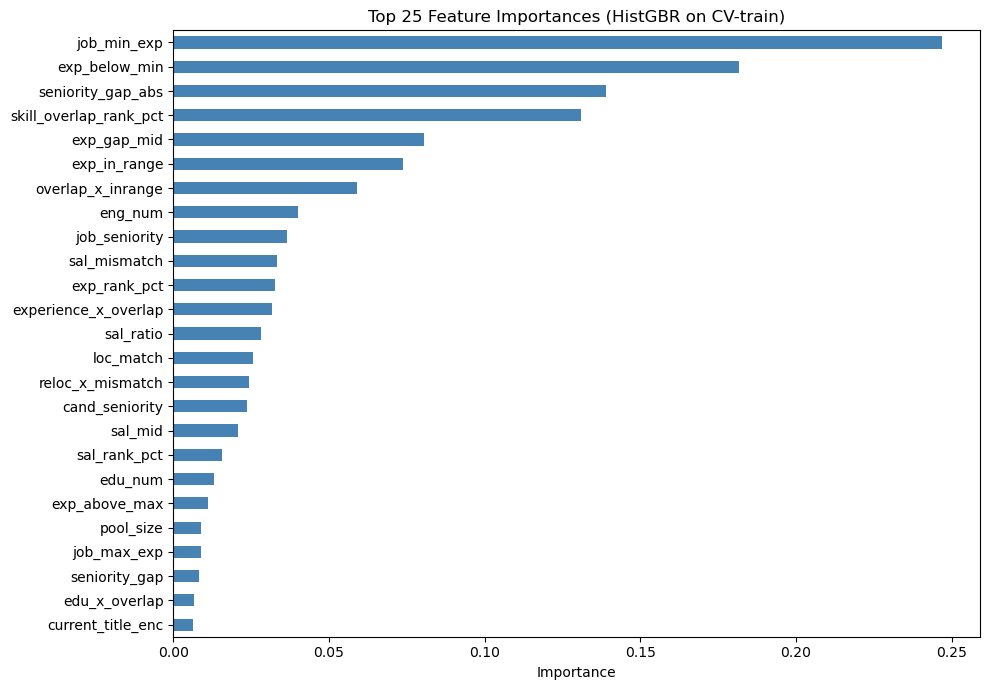

job_min_exp               0.2468
exp_below_min             0.1817
seniority_gap_abs         0.1391
skill_overlap_rank_pct    0.1311
exp_gap_mid               0.0807
exp_in_range              0.0739
overlap_x_inrange         0.0590
eng_num                   0.0401
job_seniority             0.0367
sal_mismatch              0.0335
exp_rank_pct              0.0327
experience_x_overlap      0.0319
sal_ratio                 0.0282
loc_match                 0.0255
reloc_x_mismatch          0.0244
cand_seniority            0.0236
sal_mid                   0.0209
sal_rank_pct              0.0157
edu_num                   0.0132
exp_above_max             0.0113
pool_size                 0.0089
job_max_exp               0.0088
seniority_gap             0.0083
edu_x_overlap             0.0068
current_title_enc         0.0064
dtype: float64


In [116]:
from sklearn.inspection import permutation_importance

reg_fi = HistGradientBoostingRegressor(**REGRESSOR_PARAMS)
reg_fi.fit(X_cv_train, y_cv_train)

result = permutation_importance(
    reg_fi, X_cv_train, y_cv_train, 
    n_repeats=5, random_state=42, n_jobs=-1
)

fi = pd.Series(result.importances_mean, index=X_train.columns)
fi_sorted = fi.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 7))
fi_sorted.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 25 Feature Importances (HistGBR on CV-train)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print(fi_sorted.round(4))


## 12. Final Training & Submission

In [117]:
print('Training final models on full training set...')

final_reg = HistGradientBoostingRegressor(**REGRESSOR_PARAMS)
final_clf = HistGradientBoostingClassifier(**CLASSIFIER_PARAMS)

final_reg.fit(X_train, y_train)
final_clf.fit(X_train, y_train)

print('Done training.')

test_score_reg = final_reg.predict(X_test)
test_proba = final_clf.predict_proba(X_test)
test_score_clf = test_proba @ final_clf.classes_.astype(float)

test_score_blend = 0.6 * test_score_reg + 0.4 * test_score_clf

print(f'Test scores stats: min={test_score_blend.min():.4f}, '
      f'max={test_score_blend.max():.4f}, '
      f'mean={test_score_blend.mean():.4f}')

Training final models on full training set...
Done training.
Test scores stats: min=-0.2344, max=4.5200, mean=1.1491


In [118]:
submission = pd.DataFrame({
    'application_id': apps_test['application_id'].values,
    'score': test_score_blend
})

assert len(submission) == len(apps_test), 'Row count mismatch!'
assert submission['application_id'].nunique() == len(submission), 'Duplicate application_ids!'

sub_path = 'submission69.csv'
submission.to_csv(sub_path, index=False)

print(f'Submission saved to {sub_path}')
print(f'Shape: {submission.shape}')
submission.head()

Submission saved to submission69.csv
Shape: (52700, 2)


,application_id,score
0,1,2.031908
1,2,1.586198
2,3,0.330649
3,4,2.060251
4,5,1.886309


Score distribution per job (first 10):
          min    max   mean  count
job_id                            
1       0.098  4.106  1.469     38
2      -0.174  4.009  1.165    106
3      -0.047  2.984  1.312     18
4      -0.076  3.020  1.393     16
5      -0.149  3.511  1.211     27
7       0.018  3.832  1.236     30
9      -0.152  3.852  1.178     27
11     -0.031  2.002  1.142     14
14     -0.110  3.452  1.077     53
18     -0.069  3.757  1.166    126



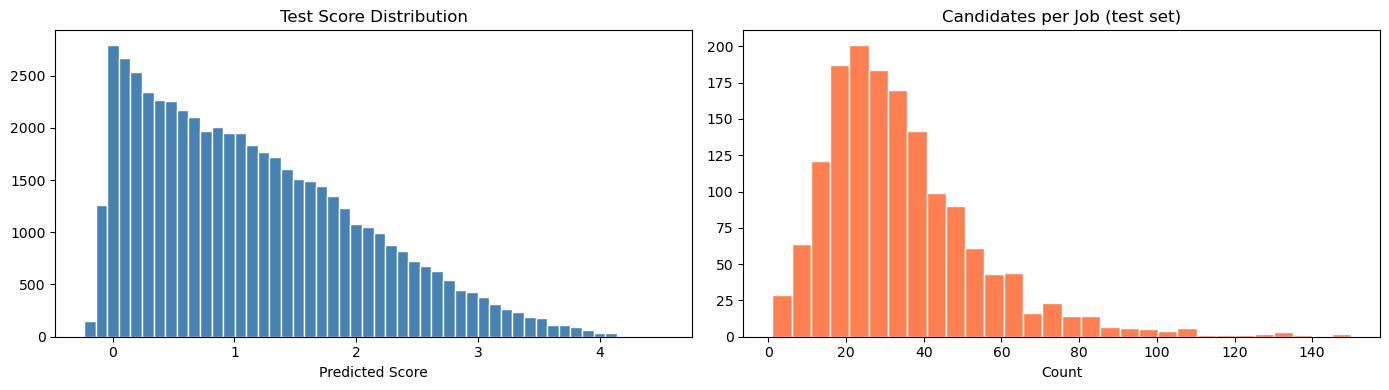

In [119]:
test_with_scores = apps_test[['application_id', 'job_id']].copy()
test_with_scores['score'] = test_score_blend

scores_per_job = test_with_scores.groupby('job_id')['score'].agg(['min', 'max', 'mean', 'count'])

print('Score distribution per job (first 10):')
print(scores_per_job.head(10).round(3))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(test_score_blend, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Test Score Distribution')
axes[0].set_xlabel('Predicted Score')

axes[1].hist(scores_per_job['count'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Candidates per Job (test set)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [120]:
print('=' * 55)
print('  PIPELINE SUMMARY')
print('=' * 55)
print(f'  Training samples  : {len(apps_train):,}')
print(f'  Test samples      : {len(apps_test):,}')
print(f'  Features          : {X_train.shape[1]}')
print(f'  CV NDCG@10        : {np.mean(fold_ndcg):.4f} ± {np.std(fold_ndcg):.4f}')
print(f'  CV MAP@5          : {np.mean(fold_map):.4f} ± {np.std(fold_map):.4f}')
print(f'  Hold-out NDCG@10  : {ndcg_ho:.4f}')
print(f'  Hold-out MAP@5    : {map5_ho:.4f}')
print(f'  Submission rows   : {len(submission):,}')
print('=' * 55)

  PIPELINE SUMMARY
  Training samples  : 118,772
  Test samples      : 52,700
  Features          : 53
  CV NDCG@10        : 0.8585 ± 0.0025
  CV MAP@5          : 0.6822 ± 0.0061
  Hold-out NDCG@10  : 0.8753
  Hold-out MAP@5    : 0.6381
  Submission rows   : 52,700
